###### Simon Steffens, ETH Zurich, June 13. 2023
### Compute warp


This notebook is the second in 3 jupyter notebooks to create an .obj file that 
warps a texture such that it is correctly displayed in a dome VR setup.

The mapping `mapping.npy` is loaded from the previous notebook. Optionally, 
the registered points are displayed in the napari viewer. To map from the points
registered in the calibration image, to the projected points in the spherical 
screen, a Clough-Tocher interpolator is used. This method achieves a smooth, 
accurate coordinate transformation. Once the model is fit to the registered 
points, it is used to transform a rectangular mesh of coordinates. This 
meshmapping is saved as `meshmapping.npy` and used for creating the final object 
file.

In [3]:
import napari
import numpy as np
from skimage.io import imread

from scipy.interpolate import CloughTocher2DInterpolator

import matplotlib.pyplot as plt

In [2]:
viewer = napari.Viewer()

In [4]:
# add empty canvas for registering points
viewer.add_image(np.full((1080,1920), .5 ))

<Image layer 'Image' at 0x7f1a71490f40>

In [5]:
# add callibration image to resgister ground truth
cimg = imread('circ_callibr_v8.png')
viewer.add_image(cimg, name='gt_callibr', opacity=.2)

<Image layer 'gt_callibr' at 0x7f1a5db60a30>

In [6]:
# load a mapping 
# points-replicates-dim(411) - proj_vs_gt-dim(2) - YX-dim(2)
mapping = np.load('mapping_v6.npy')
mapping.shape

(411, 2, 2)

In [7]:
def load_mapping_to_napari():
    # or load without ring information
    viewer.add_points(mapping[:,0], name=f'ring_proj', face_color='blue')
    viewer.add_points(mapping[:,1], name=f'ring_gt', face_color='green')

In [8]:
load_mapping_to_napari()

In [10]:
# create a grid of xy coordinates, flatten, sort 
gridsize = 10
# shape: (xy (2), Nrows, Ncols)
grid = np.mgrid[0:1920+1:gridsize,0:1080+1:gridsize]
n_cols, n_rows = grid.shape[1:]
grid_flat = np.moveaxis(grid,0,2).reshape((-1,2))
grid_flat =  grid_flat[np.lexsort((grid_flat[:,0], grid_flat[:,1]))]

# fit an interpolator to map xy-rectangular-coo to xy-projected-coo
interp = CloughTocher2DInterpolator(mapping[:,1,::-1], mapping[:,0,::-1],)
proj_grid_flat = interp(grid_flat)

# Nrows*Ncols(21037)-dim - grid-coo_proj_coo-dim - xy-dim
meshmapping = np.stack((grid_flat, proj_grid_flat), axis=1)
meshmapping = np.nan_to_num(meshmapping, nan=-1).astype(int)
meshmapping.shape, meshmapping

((21037, 2, 2),
 array([[[   0,    0],
         [  -1,   -1]],
 
        [[  10,    0],
         [  -1,   -1]],
 
        [[  20,    0],
         [  -1,   -1]],
 
        ...,
 
        [[1900, 1080],
         [  -1,   -1]],
 
        [[1910, 1080],
         [  -1,   -1]],
 
        [[1920, 1080],
         [  -1,   -1]]]))

In [15]:
n_cols, n_rows

(193, 109)

In [11]:
viewer.add_points(meshmapping[:,0,-1::-1], name=f'grid_input', 
                  face_color='white', size=1)
viewer.add_points(meshmapping[:,1,-1::-1], name=f'grid_interp_proj', 
                  face_color='red', size=1)

<Points layer 'grid_interp_proj' at 0x7f1a5d2b8850>

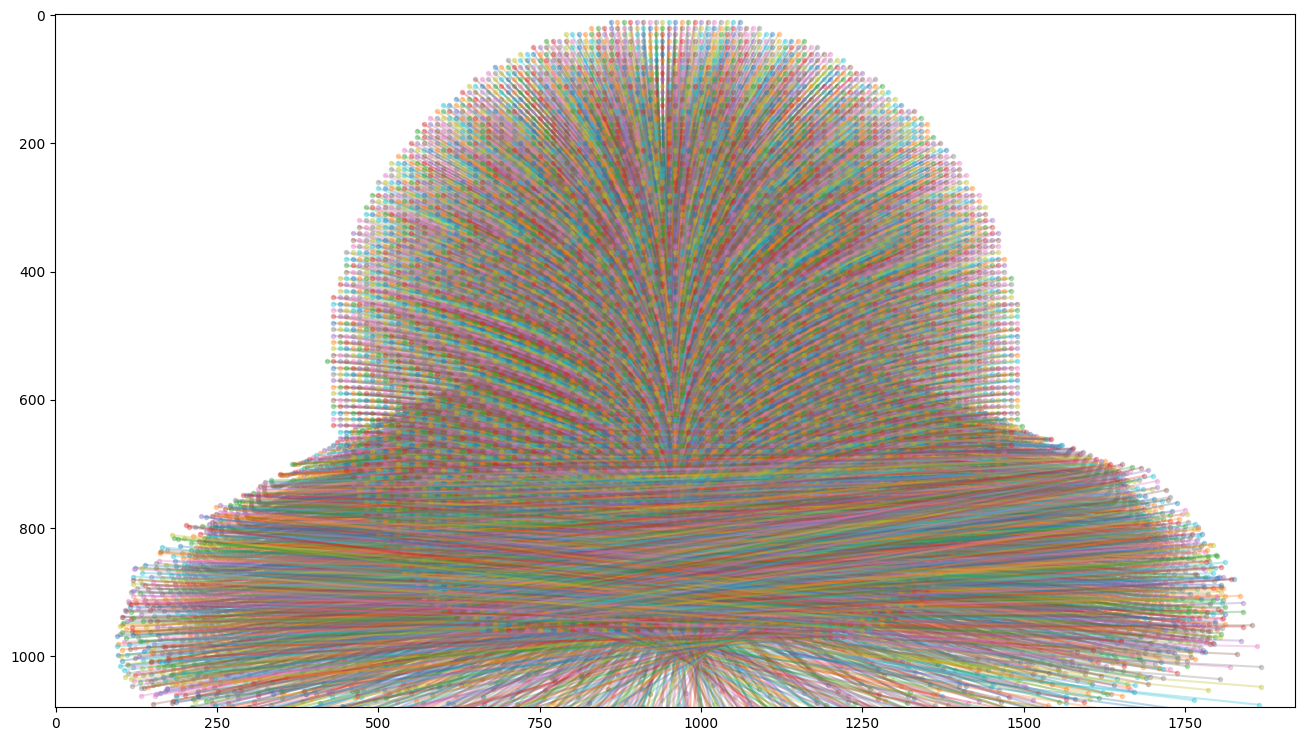

In [13]:
# validation plot connecting input grid coo with its interpolated projection
fig, ax = plt.subplots(1, figsize=(16,9))
plt.ylim([1080,-1.5])
plt.xlim([-1.5,1920])

for i in range(meshmapping.shape[0]):
    v_xy = meshmapping[i,0]
    vt_xy = meshmapping[i,1]
    if not (vt_xy == -1).all():
        ax.plot(*np.stack((v_xy, vt_xy),1), '.-', alpha=.3)

In [14]:
# save the grid-mesh and interpolated-mesh 
np.save("meshmapping_v8.npy", meshmapping)